In [1]:
import sys
import os
from pathlib import Path
import pickle
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import linregress
from xarray.coding.times import decode_cf_datetime

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Project paths
try:
    project_root = Path.cwd().parent
except NameError:
    project_root = Path('/scistor/guest/gbb083/AeroCom')
py_dir = project_root / 'py'
if str(py_dir) not in sys.path:
    sys.path.insert(0, str(py_dir))
sys.path.append(py_dir)
import functions
import cameo_toolbox as ct
import aerocom_data
import notebook_setup as setup

print(f'Project root: {project_root}')
print(f'Python dir:   {py_dir}')

Project root: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom
Python dir:   /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py


In [2]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
EXCLUDE_MODELS = ['GEOS-i33p2-met2010_AP3-CTRL-2010','GISS-ModelE2p1p1-OMA_AP3-CTRL-2010','GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010','GISS-ModelE2p1p1-MATRIX_AP3-CTRL','NorESM2-met2010_AP3-CTRL-v3']  

# Derived variables computed after regional/temporal aggregation.
# AAOD analysis uses BC+OA only; total-aerosol lifetime is not required.
DERIVED_VAR_AFTER_AGG = {'lifetime_ss', 'lifetime'}


# Deposition-based lifetime option
USE_DEPOSITION_FOR_LIFETIME = False  # True → lifetime = load / deposition; False → lifetime = load / emission

SAVE_FIGURE = False
FIGURE_DIR = project_root / 'figure'
TABLE_DIR = project_root / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
USE_PICKLE = False

# Shared regional seasonal cache (see py/build_regional_aggregates.py).
# True  → skip NetCDF load / aggregate / POLDER / GPCP / homogenize;
#         rebuild model_seasonal + obs from parquet.
# False → full pipeline (optional SAVE_AGG_CACHE refreshes the parquet).
AGG_PARQUET = TABLE_DIR / 'regional_seasonal_aggregates_ss.parquet'
USE_AGG_CACHE = False
SAVE_AGG_CACHE = False
p = Path(AGG_PARQUET)
if not p.is_file():
    USE_AGG_CACHE = False
    SAVE_AGG_CACHE = True

# MAC–x regression (x = SSA or 1-SSA, as in SSA_MEC_scatter_plot.ipynb):
#   MAC_X_COL = 'SSA'   -> MAC = F * SSA  (+ b unless INTERCEPT_0)
#   MAC_X_COL = '1-SSA' -> MAC = A * (1-SSA) (+ b unless INTERCEPT_0)
#                         Theory: MAC = MEC*(1-SSA) prefers INTERCEPT_0=True
MAC_X_COL = '1-SSA'  # or '1-SSA'
#   INTERCEPT_0 = False -> OLS with intercept (default)
#   INTERCEPT_0 = True  -> through origin (uncentered R²)
INTERCEPT_0 = True

def short_model_name(model):
    """Compact tick label: strip common AeroCom CTRL suffixes."""
    name = str(model)
    for suffix in (
        '_AP3-CTRL2016-PD', '_AP3-CTRL2016', '_AP3-CTRL-2010',
        '_AP3-CTRL2019', '_AP3-CTRL', '-met2010',
    ):
        name = name.replace(suffix, '')
    return name

# Zhong et al. POLDER-GRASP homogenization of regional AAOD used for E_C.
POLDER_HOMOGENIZE = True

# Homogenize regional SSA_obs the same way as AAOD_obs (item 2): fit
# sampled = a * regional + b from models, then invert with the raw
# POLDER-sampled SSA mean.
SSA_POLDER_HOMOGENIZE = True



In [3]:

REGIONS = {
    'global': {
        'surface_type': 'ocean',
        'lon_range': (0, 360), 'lat_range': (-90, 90),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'ARCO': {
        'surface_type': 'ocean',
        'lon_range': (0, 360), 'lat_range': (60, 90),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': True,
    },
    'NPO': {
        'surface_type': 'ocean',
        'lon_range': (120, 260), 'lat_range': (20, 60),
        'time_slice': ('2010-01-01', '2010-02-28'), 'edge_weighted': True, # CHOSE THE LOW DSM 
    },
    'TPO': {
        'surface_type': 'ocean',
        'lon_range': (120, 280), 'lat_range': (-20, 20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False, 
    },
    'SPO': {
        'surface_type': 'ocean',
        'lon_range': (120, 290), 'lat_range': (-60, -20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'NAO': {
        'surface_type': 'ocean',
        'lon_range': (280, 360), 'lat_range': (20, 60),
        'time_slice':  ('2010-01-01', '2010-02-28'), 'edge_weighted': False,
    },
    'TAO': {
        'surface_type': 'ocean',
        'lon_range': (290, 360), 'lat_range': (-20, 20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'SAO': {
        'surface_type': 'ocean',
        'lon_range': (290, 360), 'lat_range': (-60, -20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'TIO': {
        'surface_type': 'ocean',
        'lon_range': (20, 120), 'lat_range': (-20, 20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'SIO': {
        'surface_type': 'ocean',
        'lon_range': (20, 120), 'lat_range': (-60, -20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'ANTAO': {
        'surface_type': 'ocean',
        'lon_range': (0, 360), 'lat_range': (-90, -60),
        'time_slice': ('2010-01-01', '2010-03-01'), 'edge_weighted': False,
    }
}
# Source regions used for the main Fig. 3-style decomposition.
SOURCE_REGIONS = ['NAO','ANTAO']
OUTFLOW_REGION = 'outflow_af'
# OUTFLOW_SOURCE = 'africa'
# Only these regions are masked/aggregated/used in the notebook.
ANALYSIS_REGIONS = SOURCE_REGIONS #+ [OUTFLOW_REGION]

# Shared per-region color palette (used across all plots in this notebook).
REGION_COLORS = {
    'ANTAO': '#ff7f0e', 'NPO': '#2ca02c', 'outflow_af': '#9467bd',
    'indonesia_peatland': '#8c564b',
    'boreal_na_west': '#1f77b4',
}


print('\n--- Active configuration ---')
print(f'  MAC_X_COL            = {MAC_X_COL!r}')
print(f'  INTERCEPT_0          = {INTERCEPT_0}  '
      f"({'through origin' if INTERCEPT_0 else 'OLS with intercept'})")
print(f'  POLDER_HOMOGENIZE    = {POLDER_HOMOGENIZE}')  
print(f'  USE_DEPOSITION_FOR_LIFETIME = {USE_DEPOSITION_FOR_LIFETIME}  ',
      f"({'load/deposition' if USE_DEPOSITION_FOR_LIFETIME else 'load/emission'})",
      f'(CAM5 long lifetimes filtered here)')
print(f'  EXCLUDE_MODELS      = {EXCLUDE_MODELS}')
print(f'  ANALYSIS_REGIONS     = {ANALYSIS_REGIONS}')
print(f'  DERIVED_VAR_AFTER_AGG= {DERIVED_VAR_AFTER_AGG}')
print(f'  USE_AGG_CACHE         = {USE_AGG_CACHE}')
print(f'  AGG_PARQUET           = {AGG_PARQUET}')
print(f'  SAVE_FIGURE          = {SAVE_FIGURE}')
print(f'  FIGURE_DIR           = {FIGURE_DIR}')
print(f'  TABLE_DIR            = {TABLE_DIR}')



--- Active configuration ---
  MAC_X_COL            = '1-SSA'
  INTERCEPT_0          = True  (through origin)
  POLDER_HOMOGENIZE    = True
  USE_DEPOSITION_FOR_LIFETIME = False   (load/emission) (CAM5 long lifetimes filtered here)
  EXCLUDE_MODELS      = ['GEOS-i33p2-met2010_AP3-CTRL-2010', 'GISS-ModelE2p1p1-OMA_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL', 'NorESM2-met2010_AP3-CTRL-v3']
  ANALYSIS_REGIONS     = ['NAO', 'ANTAO']
  DERIVED_VAR_AFTER_AGG= {'lifetime_ss', 'lifetime'}
  USE_AGG_CACHE         = False
  AGG_PARQUET           = /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/tables/regional_seasonal_aggregates_ss.parquet
  SAVE_FIGURE          = False
  FIGURE_DIR           = /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/figure
  TABLE_DIR            = /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/tables


In [4]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping NetCDF load')
else:
    VARIABLES = [
        "od440aer", "od550aer", "od870aer", "od865aer",
        "abs550aer", "od550ss", "od550so4",
        "precip",

        # aerosol loads
        "loadbc", "loaddust", "loadoa", "loadso4", "loadss",

        # emissions
        "emibc", "emidust", "emioa", "emiso2", "emiss",

        # deposition
        "depbc", "depdust", "depoa", "depso4", "depss",
    ]
    variables_pre_aggregated = [
        'MEC', 'MAC', 'SSA', 'AE', 'MEC_ss',
        'od550so4','depso4','emiso2',
        'od550ss','loadss','depss','emiss', 
        'precip','abs550aer',
        'load_total','emi_total','dep_total'
    ] 

    print('Loading monthly data from processed NetCDF files...')
    raw_data = aerocom_data.load_monthly_data_from_netcdf(
        output_base_dir=str(project_root / 'Data' / 'AP3_processed_monthly'),
        variables=VARIABLES,
    )

    # Apply model exclusion list before any processing
    missing_excluded = [m for m in EXCLUDE_MODELS if m not in raw_data]
    if missing_excluded:
        print(f'Warning: excluded models not found in data: {missing_excluded}')
    models = sorted([m for m in raw_data.keys() if m not in EXCLUDE_MODELS])
    actually_excluded = [m for m in EXCLUDE_MODELS if m in raw_data]
    print(f'Number of models: {len(models)} (excluded {len(actually_excluded)}: {actually_excluded})')

    # Document SOA availability in processed NetCDF
    _available_vars = sorted({
        p.name for p in (project_root / 'Data' / 'AP3_processed_monthly').iterdir()
        if p.is_dir()
    }) if (project_root / 'Data' / 'AP3_processed_monthly').exists() else [] 
    print(f'Processed monthly variables: {len(_available_vars)} directories')


Loading monthly data from processed NetCDF files...
Loaded 505 NetCDF files for 30 models from /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/AP3_processed_monthly
Number of models: 26 (excluded 4: ['GISS-ModelE2p1p1-OMA_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL', 'NorESM2-met2010_AP3-CTRL-v3'])
Processed monthly variables: 29 directories


In [5]:
# OD_SS = 'od550ss'
# ssAOD_r 
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping normalize/sums')
else:
    LOAD_VARS = ["loadbc", "loaddust", "loadoa", "loadso4", "loadss"]
    EMI_VARS = ["emibc", "emidust", "emioa", "emiso2", "emiss"]
    DEP_VARS = ["depbc", "depdust", "depoa", "depso4", "depss"]
    data = {}
    for m in models:
        normalized = {}
        for var in VARIABLES:
            if raw_data[m].get(var) is None:
                continue
            try:
                normalized[var] = aerocom_data.normalize_dataset_time(raw_data[m][var], var_hint=f'{m}/{var}', year=2010)
            except Exception as e:
                print(f'  Failed to normalize {m}/{var}: {e}')
                normalized[var] = None
        normalized['load_total'] = setup.sum_datasets(
            normalized, LOAD_VARS, 'load_total', require_all=True
        )
        normalized['emi_total'] = setup.sum_datasets(
            normalized, EMI_VARS, 'emi_total', require_all=True
        )
        normalized["dep_total"] = setup.sum_deposition_datasets(
            normalized,
            DEP_VARS,
            "dep_total",
            require_all=True,
        )
        data[m] = normalized
    n_emiss = sum(1 for m in models if data[m].get('emiss') is not None)
    n_depss = sum(1 for m in models if data[m].get('depss') is not None)
    n_odss = sum(1 for m in models if data[m].get('od550ss') is not None)
    print(f'  od550ss available: {n_odss}/{len(models)} ')
    print(f'  ses salt emission available: {n_emiss}/{len(models)} models ')
    print(f'  ses salt deposition available:{n_depss}/{len(models)} models ')

    # -- add target_model list from the model that exits both in emiss and od550ss--
    tar_var = "depss" if USE_DEPOSITION_FOR_LIFETIME else 'od550ss'
    target_models = [
    m for m in models
        if data[m].get("od550aer") is not None
        and data[m].get("od550ss") is not None
        and data[m].get("loadss") is not None
    ]

  od550ss available: 24/26 
  ses salt emission available: 23/26 models 
  ses salt deposition available:12/26 models 


In [6]:
# od = data[m].get('od550aer')
# ld = data[m].get('loadss')

# if od is None or ld is None:
#     raise KeyError(f"Missing od550aer or loadss for model {m}")

# MEC = od / (ld * 1e3)
# print(ld)
# mec_da = od['od550aer'] / (ld['loadss'] * 1e3)
# mec_da.isel(time=0).plot(figsize=(8, 4))
# plt.title(f"{m} MEC (time=0)")
# plt.show()

In [8]:
# odSS = data[m].get('od550ss')
# ss_r = odSS['od550ss'] / od['od550aer']
# ss_r.isel(time=0).plot(figsize=(8, 4))
# plt.title(f"{m} ss_aod / aod (time=0)")
# plt.show()
# odS04 = data[m].get('od550so4')
# so4_r = odS04['od550so4'] / od['od550aer']
# so4_r.isel(time=0).plot(figsize=(8, 4))
# plt.title(f"{m} so4_aod / aod (time=0)")
# plt.show()
# ssso4_r = (odSS['od550ss'] + odS04['od550so4']) / od['od550aer']
# ssso4_r.isel(time=0).plot(figsize=(8, 4))
# plt.title(f"{m} sea salt + so4  / aod (time=0)")
# plt.show()

In [9]:
import logging

from aerocom_data import _get_dataarray, _align_da_to_ref

if USE_AGG_CACHE:
    print("USE_AGG_CACHE=True: skipping pre-aggregation derived vars")
else:
    derived_vars_pre = [
        dv for dv in ["MEC", "MEC_ss", "SSA", "AE", "MAC"]
        if dv not in DERIVED_VAR_AFTER_AGG
    ]
    derived = {m: {} for m in models}

    # Align available sibling fields to od550aer.
    for m in target_models:
        aerocom_data.align_model_grids(
            data[m],
            ref_var="od550aer",
            model_hint=m,
        )

    print(f"Grid-aligned {len(target_models)} models onto od550aer when available.")
    ss_models = []

    for m in target_models:
        model_data = data[m]
        aod550 = _get_dataarray(model_data.get("od550aer"), "od550aer")

        if aod550 is None:
            logging.warning("Skipping %s: missing od550aer.", m)
            continue

        # Total aerosol load is needed only for MEC and MAC.
        load_keys = ["loadbc", "loaddust", "loadoa", "loadso4", "loadss"]
        loads = []

        for key in load_keys:
            load_da = _get_dataarray(model_data.get(key), key)
            if load_da is not None:
                loads.append(
                    _align_da_to_ref(load_da, aod550, model_hint=f"{m}/{key}")
                )

        total_load = sum(loads) if loads else None
        derived[m]["total_load"] = (
            total_load.to_dataset(name="total_load")
            if total_load is not None
            else None
        )

        # Sea-salt eligibility: only these three fields are required.
        aod_ss = _get_dataarray(model_data.get("od550ss"), "od550ss")
        load_ss = _get_dataarray(model_data.get("loadss"), "loadss")

        if aod_ss is not None and load_ss is not None:
            ss_models.append(m)

        for dv in derived_vars_pre:
            ds = None

            try:
                if dv == "MEC":
                    if total_load is None:
                        raise KeyError("No aerosol load components available.")
                    ds = (aod550 / (total_load * 1e3)).to_dataset(name="MEC")

                elif dv == "MEC_ss":
                    if aod_ss is None or load_ss is None:
                        raise KeyError("Missing od550ss or loadss.")

                    aod_ss = _align_da_to_ref(
                        aod_ss, aod550, model_hint=f"{m}/od550ss"
                    )
                    load_ss = _align_da_to_ref(
                        load_ss, aod550, model_hint=f"{m}/loadss"
                    )
                    ds = (aod_ss / (load_ss * 1e3)).to_dataset(name="MEC_ss")

                elif dv == "SSA":
                    aaod = _get_dataarray(model_data.get("abs550aer"), "abs550aer")
                    if aaod is None:
                        raise KeyError("Missing abs550aer.")

                    aaod = _align_da_to_ref(
                        aaod, aod550, model_hint=f"{m}/abs550aer"
                    )
                    ds = (1.0 - aaod / aod550).to_dataset(name="SSA")

                elif dv == "MAC":
                    aaod = _get_dataarray(model_data.get("abs550aer"), "abs550aer")
                    if aaod is None or total_load is None:
                        raise KeyError("Missing abs550aer or total_load.")

                    aaod = _align_da_to_ref(
                        aaod, aod550, model_hint=f"{m}/abs550aer"
                    )
                    ds = (aaod / (total_load * 1e3)).to_dataset(name="MAC")

                elif dv == "AE":
                    aod_other = None
                    other_wavelength = None

                    for var_name, wavelength in [
                        ("od870aer", 870),
                        ("od865aer", 865),
                        ("od440aer", 440),
                    ]:
                        candidate = _get_dataarray(model_data.get(var_name), var_name)
                        if candidate is not None:
                            aod_other = candidate
                            other_wavelength = wavelength
                            break

                    if aod_other is None:
                        raise KeyError("Missing od440aer, od865aer, and od870aer.")

                    aod_other = _align_da_to_ref(
                        aod_other, aod550, model_hint=f"{m}/spectral_aod"
                    )
                    ds = (
                        -np.log(aod550 / aod_other)
                        / np.log(550.0 / other_wavelength)
                    ).to_dataset(name="AE")

            except (KeyError, ValueError, ZeroDivisionError) as exc:
                logging.warning("Could not calculate %s for %s: %s", dv, m, exc)

            derived[m][dv] = (
                ds[list(ds.data_vars)[0]]
                if ds is not None
                else None
            )

        derived[m]["lifetime"] = None
        derived[m]["lifetime_ss"] = None

    print(f"Sea-salt eligible models: {len(ss_models)}/{len(target_models)}")

    data_derived = {}
    for m in models:
        data_derived[m] = {}

        for key, dataset in data[m].items():
            if dataset is not None:
                data_derived[m][key] = dataset[list(dataset.data_vars)[0]]

        for key, value in derived[m].items():
            if value is not None:
                data_derived[m][key] = value

INFO:   Grid-aligned od440aer -> od550aer for CAM5_CTRL2016/od440aer
INFO:   Grid-aligned od440aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/od440aer
INFO:   Grid-aligned od870aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/od870aer
INFO:   Grid-aligned abs550aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/abs550aer


Grid-aligned 23 models onto od550aer when available.


Sea-salt eligible models: 23/23


In [10]:
# ss_models
# ANALYSIS_REGIONS
# REGIONS['NAO']
# data_derived[m]['abs550aer']
# total_load

In [11]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping regional aggregation')
else:
    SURFACE_TYPE = 'ocean'  # 'all', 'land', 'ocean', or None to use per-region defaults

    template = data[ss_models[0]]['od550aer'].isel(time=0)
    masks = {}
    for name in ANALYSIS_REGIONS:
        

        cfg = REGIONS[name]
        masks[name] = ct.create_region_mask(
            template,
            name=name,  # custom region name
            lon_range=cfg["lon_range"],
            lat_range=cfg["lat_range"],
            surface_type=cfg.get("surface_type", "all"),  # or SURFACE_TYPE override if you want
            mask_registry=masks,
        )
    print('Regions created (ANALYSIS_REGIONS):', list(masks.keys()))
    
    variables_to_aggregate = [v for v in variables_pre_aggregated if v not in DERIVED_VAR_AFTER_AGG]
    model_monthly = {
        region: {
            var: setup.aggregate_region(data_derived, var, region, masks, region=REGIONS, return_time_series=True,
                                  skipna=(var in variables_to_aggregate))
            for var in variables_to_aggregate
        }
        for region in ANALYSIS_REGIONS
    }
    model_seasonal = {
        region: {
            var: setup.aggregate_region(data_derived, var, region, masks, region=REGIONS, return_time_series=False,
                                  skipna=(var in variables_to_aggregate))
            for var in variables_to_aggregate
        }
        for region in ANALYSIS_REGIONS
    }


Regions created (ANALYSIS_REGIONS): ['NAO', 'ANTAO']



--- Regional map ---
  Background field from CAM5-ATRAS_AP3-CTRL


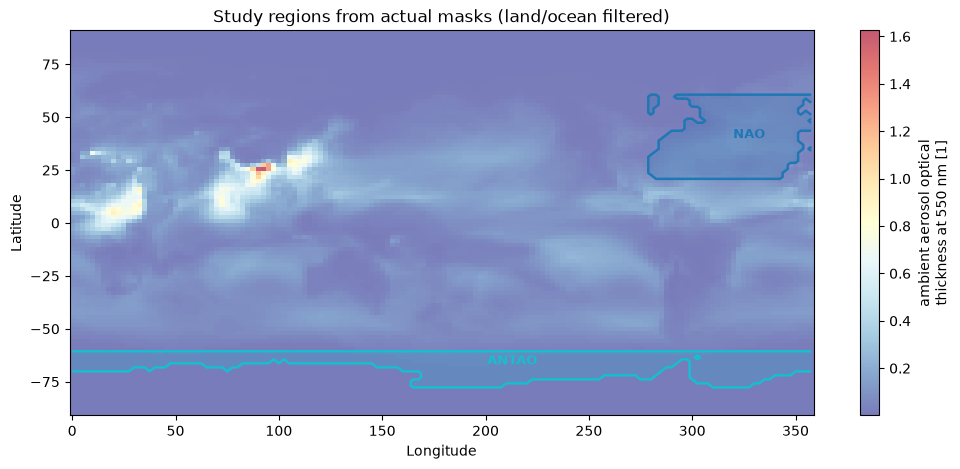

In [ ]:
# print('\n--- Regional map ---')
# # Prefer in-memory `data` from the full pipeline; otherwise load one NetCDF field.
# _sample_field = None
# _sample_model = None
# if 'data' in dir() and data:
#     _sample_model = next(
#         (m for m in models if data.get(m) and data[m].get('od550aer') is not None),
#         None,
#     )
#     if _sample_model is not None:
#         _ds = data[_sample_model]['od550aer']
#         _sample_field = _ds['od550aer'] if hasattr(_ds, '__contains__') and 'od550aer' in _ds else (
#             _ds[list(_ds.data_vars)[0]] if hasattr(_ds, 'data_vars') else _ds
#         )
#         if 'time' in getattr(_sample_field, 'dims', ()):
#             _sample_field = _sample_field.isel(time=0)

# if _sample_field is None:
#     _candidates = list(models) if 'models' in dir() and models else []
#     for _m in _candidates:
#         _fpath = project_root / 'Data' / 'AP3_processed_monthly' / 'od550aer' / f'{_m}_od550aer_processed.nc'
#         if not _fpath.exists():
#             continue
#         _ds = xr.open_dataset(_fpath, engine='netcdf4')
#         _ds = aerocom_data.standardize_dataset(_ds, 'od550aer').load()
#         _ds.close()
#         _ds = aerocom_data.normalize_dataset_time(_ds, var_hint=f'{_m}/od550aer', year=2010)
#         _sample_field = _ds[list(_ds.data_vars)[0]].isel(time=0)
#         _sample_model = _m
#         if 'data' not in dir() or data is None:
#             data = {}
#         data.setdefault(_m, {})['od550aer'] = _ds
#         break

# if _sample_field is None:
#     raise FileNotFoundError(
#         'Could not load a background od550aer field for the study-regions map. '
#         'Check Data/AP3_processed_monthly/od550aer/ or set USE_AGG_CACHE=False.'
#     )
# sample_model = _sample_model
# sample_field = _sample_field
# print(f'  Background field from {sample_model}')

# bg = sample_field
# if "time" in bg.dims:
#     bg = bg.isel(time=0)

# fig, ax = plt.subplots(figsize=(12, 5))
# bg.plot(ax=ax, cmap="RdYlBu_r", add_colorbar=True, alpha=0.65)

# # one color per region
# colors = plt.cm.tab10(np.linspace(0, 1, max(len(ANALYSIS_REGIONS), 1)))

# for i, name in enumerate(ANALYSIS_REGIONS):
#     m = masks[name]
#     if "time" in m.dims:
#         m = m.isel(time=0)
#     m = m.astype(float)

#     # fill masked area lightly
#     ax.contourf(
#         m["lon"], m["lat"], m.values,
#         levels=[0.5, 1.5], colors=[colors[i]], alpha=0.20
#     )
#     # draw exact mask boundary
#     ax.contour(
#         m["lon"], m["lat"], m.values,
#         levels=[0.5], colors=[colors[i]], linewidths=1.8
#     )

#     # label near center of masked pixels
#     yy, xx = np.where(np.isfinite(m.values) & (m.values > 0.5))
#     if len(xx) > 0:
#         lon_c = float(m["lon"].values[xx].mean())
#         lat_c = float(m["lat"].values[yy].mean())
#         ax.text(lon_c, lat_c, name, color=colors[i], fontsize=9, weight="bold")

# ax.set_title("Study regions from actual masks (land/ocean filtered)")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# if SAVE_FIGURE:
#     save_path = FIGURE_DIR / "seasalt_regions_mask_map.png"
#     fig.savefig(save_path, dpi=300, bbox_inches="tight")
#     print(f"Saved regional mask map: {save_path}")

# plt.show()

In [ ]:
# if USE_AGG_CACHE:
#     print("USE_AGG_CACHE=True: skipping post-aggregation lifetimes")
# else:
#     # Sea-salt lifetime:
#     #   emission path:  loadss / emiss
#     #   deposition path: loadss / depss
#     ss_flux_key = "depss" if USE_DEPOSITION_FOR_LIFETIME else "emiss"

#     # Total aerosol lifetime:
#     #   emission path:  load_total / emi_total
#     #   deposition path: load_total / dep_total
#     total_flux_key = "dep_total" if USE_DEPOSITION_FOR_LIFETIME else "emi_total"

#     for agg_name, agg in (
#         ("monthly", model_monthly),
#         ("seasonal", model_seasonal),
#     ):
#         for region in ANALYSIS_REGIONS:

#             # --- Sea-salt lifetime ---
#             load_ss = agg[region].get("loadss", {})
#             flux_ss = agg[region].get(ss_flux_key, {})

#             if load_ss and flux_ss:
#                 agg[region]["lifetime_ss"] = setup._lifetime_from_load_flux(
#                     load_ss,
#                     flux_ss,
#                     "lifetime_ss",
#                     region,
#                 )
#             else:
#                 agg[region]["lifetime_ss"] = {}

#             # --- Total aerosol lifetime ---
#             load_total = agg[region].get("load_total", {})
#             flux_total = agg[region].get(total_flux_key, {})

#             if load_total and flux_total:
#                 agg[region]["lifetime"] = setup._lifetime_from_load_flux(
#                     load_total,
#                     flux_total,
#                     "lifetime",
#                     region,
#                 )
#             else:
#                 agg[region]["lifetime"] = {}

#             print(
#                 f"{agg_name:8s} {region}: "
#                 f"lifetime_ss={len(agg[region]['lifetime_ss'])}, "
#                 f"lifetime={len(agg[region]['lifetime'])}"
#             )

#     # # Filter nonphysical total and sea-salt lifetimes.
#     # setup.filter_lifetime_after_agg(
#     #     model_monthly,
#     #     model_seasonal,
#     #     max_days=365,
#     #     min_days=1e-3,
#     # )
if USE_AGG_CACHE:
    print("USE_AGG_CACHE=True: skipping post-aggregation lifetimes")
else:
    LIFETIME_SPECS = {
        'lifetime_ss':  ('loadss',      'depss' if USE_DEPOSITION_FOR_LIFETIME else 'emiss'),
        'lifetime':     ('load_total',  'dep_total' if USE_DEPOSITION_FOR_LIFETIME else 'emi_total'),
        'lifetime_so4': ('loadso4',     'depso4'),
    }
    for agg_name, agg in (("monthly", model_monthly), ("seasonal", model_seasonal)):
        for region in ANALYSIS_REGIONS:
            for out_key, (load_key, flux_key) in LIFETIME_SPECS.items():
                load, flux = agg[region].get(load_key, {}), agg[region].get(flux_key, {})
                agg[region][out_key] = (
                    setup._lifetime_from_load_flux(load, flux, out_key, region) if load and flux else {}
                )

monthly  NAO: lifetime_ss=23, lifetime=13
monthly  ANTAO: lifetime_ss=23, lifetime=13
seasonal NAO: lifetime_ss=23, lifetime=13
seasonal ANTAO: lifetime_ss=23, lifetime=13


In [13]:
# import notebook_setup as setup
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping regional aggregation')
else:
    model_monthly_df, model_seasonal_df = setup.convert_aggregation_to_dataframes(
        model_monthly, model_seasonal, month_col='month'
    )

    display(model_seasonal_df.head())
    display(model_monthly_df.head())
    # m = masks["ANTAO"]
    # print("sum=", float(m.sum()), "min=", float(m.min()), "max=", float(m.max()))
    # m.plot()  # direct check
    for region in SOURCE_REGIONS:
        reg_data = model_seasonal.get(region, {})

        ae_dict = reg_data.get("AE", {})
        lifetime_dict = reg_data.get("lifetime_ss", {})
        precip_dict = reg_data.get("precip", {})

        print(f"\n{region}")
        print("  AE models:         ", len(ae_dict))
        print("  lifetime_ss models:", len(lifetime_dict))
        print("  precip models:     ", len(precip_dict))
        print("  AE ∩ lifetime:     ", len(set(ae_dict) & set(lifetime_dict)))
        print("  AE ∩ tau ∩ precip: ", len(set(ae_dict) & set(lifetime_dict) & set(precip_dict)))

        # for model in sorted(set(ae_dict) & set(lifetime_dict) & set(precip_dict)):
        #     print(
        #         f"  {model}: "
        #         f"AE={scalar_value(ae_dict[model]):.4g}, "
        #         f"tau={scalar_value(lifetime_dict[model]):.4g}, "
        #         f"precip={scalar_value(precip_dict[model]):.4g}"
        #     )

,region,model,MEC,MAC,SSA,AE,MEC_ss,od550so4,emiso2,od550ss,...,emiss,precip,abs550aer,emi_total,lifetime_ss,load_total,lifetime,depso4,depss,dep_total
0,ANTAO,CAM5-ATRAS_AP3-CTRL,2.436675,0.014555,0.993703,0.192205,2.519493,0.000639,2.389719e-14,0.011808,...,3.955878e-10,2.048624,0.000038,3.956106e-10,0.132928,NaN,NaN,NaN,NaN,NaN
1,ANTAO,CAM5.3-Oslo_AP3-CTRL2016-PD,7.651886,0.064337,0.990079,0.216694,10.368413,0.004863,7.925463e-14,0.039811,...,1.217056e-10,1.963056,0.000309,1.228767e-10,0.382976,0.000006,0.596169,NaN,NaN,NaN
2,ANTAO,CAM5_CTRL2016,3.139762,0.049198,0.983710,4.043021,2.711577,0.002697,1.515468e-14,0.016821,...,NaN,2.033953,0.000220,NaN,NaN,0.000007,NaN,6.132355e-14,NaN,NaN
3,ANTAO,EC-Earth3-AerChem-met2010_AP3-CTRL2019,5.790977,0.092052,0.983897,1.031627,5.178481,0.016531,6.657044e-14,0.034530,...,3.212197e-10,1.964915,0.000857,NaN,0.242518,0.000010,NaN,2.858163e-12,3.294993e-10,3.331490e-10
4,ANTAO,ECHAM6-HAM2_AP3-CTRL2016-PD,4.300533,NaN,NaN,NaN,0.341796,0.002286,5.153297e-14,0.002780,...,5.658705e-10,0.002176,NaN,5.659221e-10,0.181653,0.000011,0.230732,8.124826e-12,5.780789e-10,5.877688e-10


,region,model,month,MEC,MAC,SSA,AE,MEC_ss,od550so4,emiso2,...,emiss,precip,abs550aer,emi_total,lifetime_ss,load_total,lifetime,depso4,depss,dep_total
0,ANTAO,CAM5-ATRAS_AP3-CTRL,2010-01,2.349658,0.015001,0.993123,0.292298,2.502172,0.001016,2.390853e-14,...,2.671634e-10,1.621788,0.000037,2.671818e-10,0.121625,NaN,NaN,NaN,NaN,NaN
1,ANTAO,CAM5-ATRAS_AP3-CTRL,2010-02,2.423704,0.012748,0.994341,0.162377,2.484459,0.000575,2.383204e-14,...,3.918046e-10,1.985635,0.000039,3.918270e-10,0.144558,NaN,NaN,NaN,NaN,NaN
2,ANTAO,CAM5-ATRAS_AP3-CTRL,2010-03,2.536661,0.015916,0.993646,0.121939,2.571849,0.000326,2.395101e-14,...,5.277955e-10,2.538448,0.000039,5.278231e-10,0.130017,NaN,NaN,NaN,NaN,NaN
3,ANTAO,CAM5.3-Oslo_AP3-CTRL2016-PD,2010-01,8.037794,0.071582,0.989867,0.269857,11.635200,0.006310,8.669158e-14,...,8.110138e-11,1.546393,0.000329,8.211585e-11,0.391559,0.000005,0.769008,NaN,NaN,NaN
4,ANTAO,CAM5.3-Oslo_AP3-CTRL2016-PD,2010-02,7.650990,0.060102,0.990922,0.200007,10.008385,0.004973,8.235188e-14,...,1.225124e-10,1.895095,0.000307,1.237780e-10,0.402182,0.000007,0.614120,NaN,NaN,NaN



NAO
  AE models:          21
  lifetime_ss models: 23
  precip models:      18
  AE ∩ lifetime:      20
  AE ∩ tau ∩ precip:  16


NameError: name 'scalar_value' is not defined

In [14]:


print("\nSeasonal availability:")
availability_columns = [
    var for var in ["MEC_ss", "MAC", "SSA", "AE", "lifetime_ss", "lifetime", "precip", "abs550aer"]
    if var in model_seasonal_df.columns
]
availability = model_seasonal_df.groupby("region")[availability_columns].count()
display(availability)



Seasonal availability:


,MEC_ss,MAC,SSA,AE,lifetime_ss,lifetime,precip,abs550aer
region,,,,,,,,
ANTAO,23,21,21,21,23,13,18,24
NAO,23,21,21,21,23,13,18,24


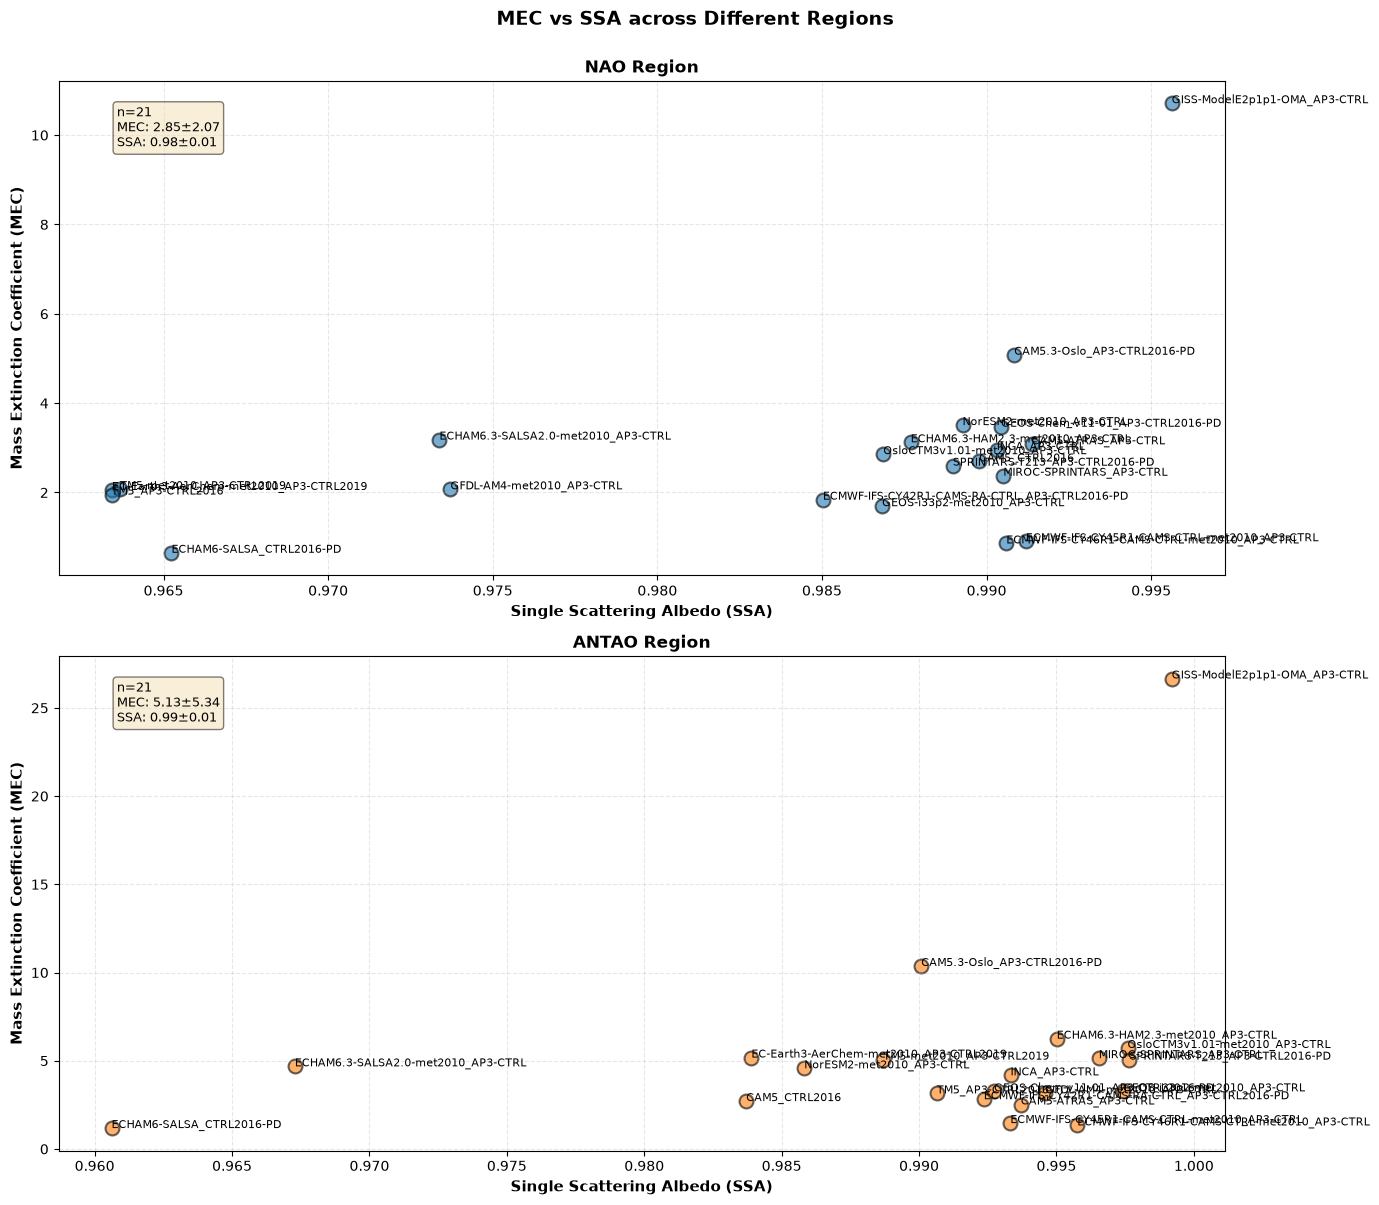

✓ Scatter plot saved as 'SSA_MEC_scatter_plot.png'


In [ ]:
if not model_seasonal_df.empty: 
    fig, axes = plt.subplots(2, 1, figsize=(14, 12))

    axes = axes.flatten()
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for idx, region in enumerate(SOURCE_REGIONS):
        ax = axes[idx]

        plot_df = model_seasonal_df.loc[
            model_seasonal_df['region'] == region,
            ['model', 'SSA', 'MEC_ss'],
        ].rename(columns={'MEC_ss': 'MEC'}).dropna()

        scatter = ax.scatter(
            plot_df['SSA'], plot_df['MEC'],
            s=100, alpha=0.6, color=colors[idx],
            edgecolors='black', linewidth=1.5
        )
        
        # Add labels for each point (model name)
        for _, row in plot_df.iterrows():
            ax.text(row['SSA'], row['MEC'], row['model'], fontsize=8)
        
        # Labels and title
        ax.set_xlabel('Single Scattering Albedo (SSA)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Mass Extinction Coefficient (MEC)', fontsize=11, fontweight='bold')
        ax.set_title(f'{region.upper()} Region', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Add statistics box
        stats_text = f"n={len(plot_df)}\nMEC: {plot_df['MEC'].mean():.2f}±{plot_df['MEC'].std():.2f}\nSSA: {plot_df['SSA'].mean():.2f}±{plot_df['SSA'].std():.2f}"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
               fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('MEC vs SSA across Different Regions', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    if SAVE_FIGURE:
        save_path = FIGURE_DIR / "SSA_MECss_scatter_plot.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved regional mask map: {save_path}")
    plt.show()
    print("✓ Scatter plot saved as 'SSA_MEC_scatter_plot.png'")
else:
    print("✗ No region data available for plotting")

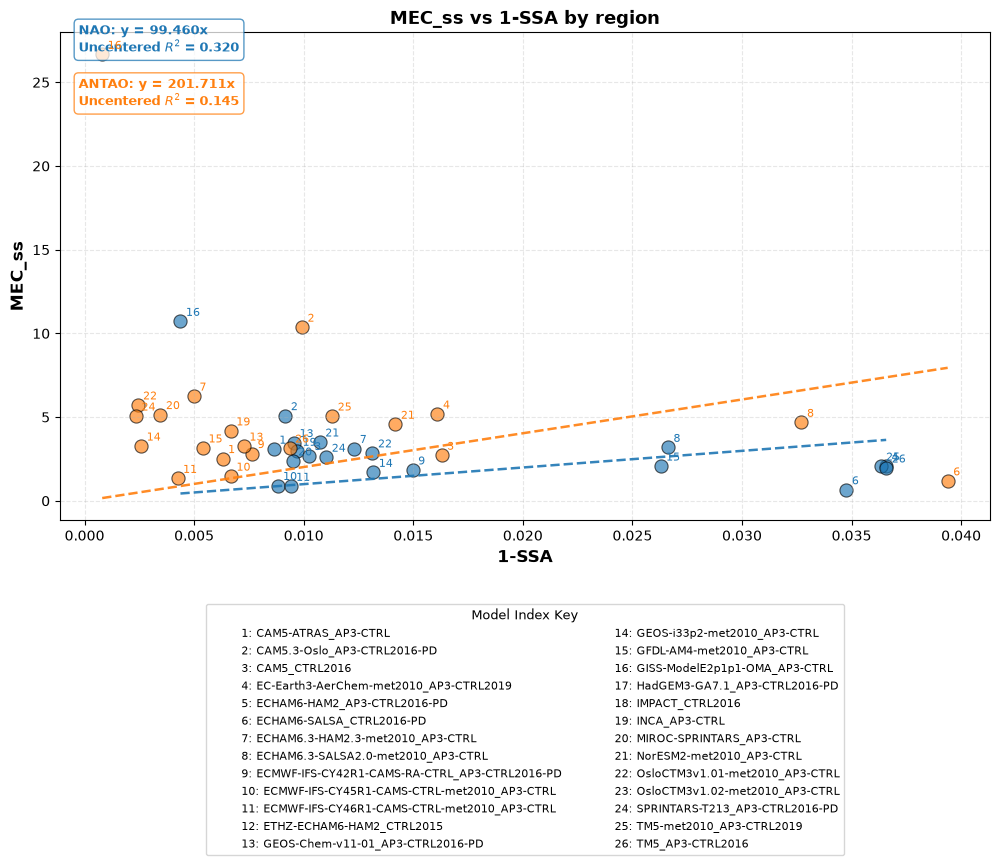

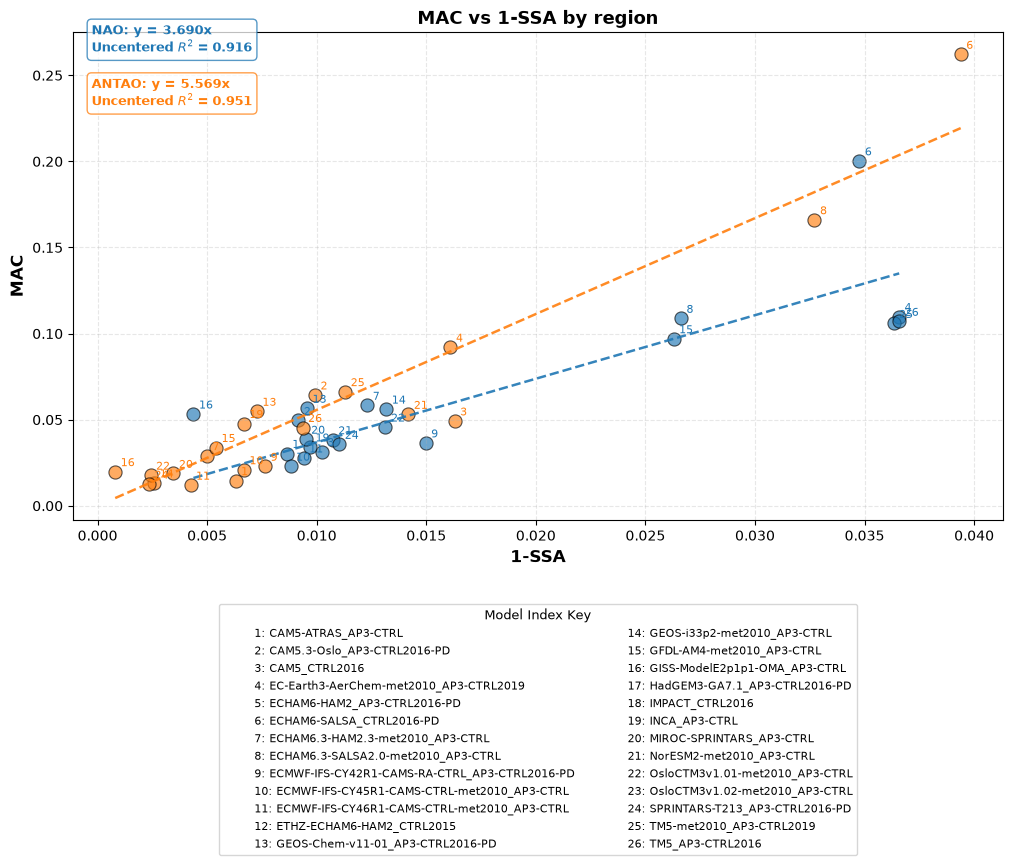

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plot_combined_regions(
    model_seasonal_df,
    x_col='SSA',
    y_col='MEC_ss',
    x_label='SSA',
    y_label='MEC_ss',
    title=None,
    use_model_numbers=True,
    force_intercept_zero=False,
    save_fig=False,
    filename='combined_regions.png',
):
    """
    Expects one seasonal row per region/model, with variables in columns.
    """

    if model_seasonal_df.empty:
        print("model_seasonal_df is empty.")
        return

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    # collect all model names
    all_models = sorted(model_seasonal_df['model'].dropna().unique())
    model_to_num = {m: i + 1 for i, m in enumerate(all_models)}

    for idx, region in enumerate(SOURCE_REGIONS):
        columns = ['model', y_col, 'SSA' if x_col == '1-SSA' else x_col]
        df = model_seasonal_df.loc[
            model_seasonal_df['region'] == region, columns
        ].copy()
        if x_col == '1-SSA':
            df[x_col] = 1.0 - df['SSA']
        df = df[['model', x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()

        if df.empty or len(df) < 2:
            print(f"Skipping {region}: insufficient valid points.")
            continue

        x = df[x_col].to_numpy(dtype=float)
        y = df[y_col].to_numpy(dtype=float)

        color = colors[idx % len(colors)]
        ax.scatter(x, y, s=90, alpha=0.65, color=color, edgecolors='black', linewidth=0.8, label=region.upper())

        # annotate model numbers/names
        for _, row in df.iterrows():
            txt = str(model_to_num[row['model']]) if use_model_numbers else str(row['model'])
            ax.annotate(txt, (row[x_col], row[y_col]), xytext=(4, 4), textcoords='offset points', fontsize=8, color=color)

        # regression
        if force_intercept_zero:
            denom = np.dot(x, x)
            if denom <= 0:
                print(f"Skipping fit for {region}: zero x variance.")
                continue
            slope = np.dot(x, y) / denom
            intercept = 0.0
            y_fit = slope * x
            ss_res = np.sum((y - y_fit) ** 2)
            ss_tot0 = np.sum(y ** 2)
            r2 = 1 - ss_res / ss_tot0 if ss_tot0 > 0 else np.nan
            eq_str = f"y = {slope:.3f}x"
            r2_label = "Uncentered $R^2$"
        else:
            if np.unique(x).size < 2:
                print(f"Skipping fit for {region}: no x spread.")
                continue
            slope, intercept, r_value, _, _ = linregress(x, y)
            r2 = r_value**2
            sign = "+" if intercept >= 0 else "-"
            eq_str = f"y = {slope:.3f}x {sign} {abs(intercept):.3f}"
            r2_label = "$R^2$"

        x_line = np.linspace(np.min(x), np.max(x), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, '--', color=color, alpha=0.9, linewidth=1.8)

        stats_txt = f"{region.upper()}: {eq_str}\n{r2_label} = {r2:.3f}"
        ax.text(
            0.02, 0.96 - idx * 0.11, stats_txt,
            transform=ax.transAxes, color=color, fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.75, edgecolor=color)
        )

    ax.set_title(title or f"{y_col} vs {x_col} by region", fontsize=13, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=12, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(title="Regions", loc="upper right")

    if use_model_numbers and all_models:
        legend_elements = [
            plt.Line2D([0], [0], marker='', color='w', label=f"{i+1}: {m}")
            for i, m in enumerate(all_models)
        ]
        ax.legend(
            handles=legend_elements,
            title="Model Index Key",
            loc='upper center',
            bbox_to_anchor=(0.5, -0.16),
            fontsize=8,
            title_fontsize=9,
            ncol=2
        )
        plt.subplots_adjust(bottom=0.27)

    if save_fig:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")

    plt.show()
plot_combined_regions(
    model_seasonal_df,
    x_col='1-SSA',
    y_col='MEC_ss',
    x_label='1-SSA',
    y_label='MEC_ss',
    force_intercept_zero=True,
    use_model_numbers=True
)
plot_combined_regions(
    model_seasonal_df,
    x_col='1-SSA',
    y_col='MAC',
    x_label='1-SSA',
    y_label='MAC',
    force_intercept_zero=True,
    use_model_numbers=True
)


## POLDER observation 

In [15]:
if USE_AGG_CACHE:
    print("USE_AGG_CACHE=True: skipping POLDER load (from parquet)")
else:
    polder_path = project_root / "Data" / "AP3_POLDER_Collocated" / "POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet"
    print(f"\nLoading POLDER observations: {polder_path}")

    polder_cols = ["time", "longitude", "latitude", "AOD_550", "AAOD_550", "AOD_440", "AOD_870"]
    polder_df = pd.read_parquet(polder_path, columns=polder_cols)

    polder_df["time"] = pd.to_datetime(polder_df["time"])
    polder_df["month"] = polder_df["time"].dt.to_period("M")

    # keep lon convention consistent with mask grid (0..360)
    polder_df["lon360"] = (polder_df["longitude"] + 360.0) % 360.0

    with np.errstate(divide="ignore", invalid="ignore"):
        polder_df["SSA"] = 1.0 - polder_df["AAOD_550"] / polder_df["AOD_550"]
        polder_df["AE"] = -np.log(polder_df["AOD_550"] / polder_df["AOD_870"]) / np.log(550.0 / 870.0)

    polder_df = polder_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["SSA", "AE", "AAOD_550", "AOD_550"])
    print(f"POLDER rows after filtering: {len(polder_df)}")

    # Build masks once if not already present
    if "masks" not in globals() or not masks:
        template = data[ss_models[0]]["od550aer"].isel(time=0)
        masks = setup.create_analysis_masks(template, ANALYSIS_REGIONS, region=REGIONS, surface_type=None)

    def polder_monthly_means_mask(df, region_name, masks_dict, reg_cfg):
        """Use existing xarray regional mask (same as model/GPCP path)."""
        cfg = reg_cfg[region_name]
        m = masks_dict[region_name]

        # sample mask value at each POLDER point
        mask_vals = m.interp(
            lon=xr.DataArray(df["lon360"].to_numpy(), dims="points"),
            lat=xr.DataArray(df["latitude"].to_numpy(), dims="points"),
            method="nearest",
        ).values

        sub = df[np.isfinite(mask_vals) & (mask_vals > 0.5)].copy()

        t0, t1 = cfg["time_slice"]
        sub = sub[(sub["time"] >= pd.Timestamp(t0)) & (sub["time"] <= pd.Timestamp(t1))]
        if sub.empty:
            return pd.DataFrame()

        sub["coslat"] = np.cos(np.deg2rad(sub["latitude"]))

        rows = []
        for month, g in sub.groupby("month"):
            if len(g) < 3:
                continue
            w = g["coslat"].to_numpy()
            rows.append({
                "month": month,
                "time": pd.Timestamp(month.start_time),
                "SSA": np.average(g["SSA"], weights=w),
                "AE": np.average(g["AE"], weights=w),
                "AAOD_550": np.average(g["AAOD_550"], weights=w),
                "AOD_550": np.average(g["AOD_550"], weights=w),
                "n": len(g),
            })
        return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)
    def polder_monthly_means_mask(df, region_name, masks_dict, reg_cfg):
        """
        Area-weighted POLDER monthly means using the existing xarray regional mask.

        `masks_dict[region_name]` is interpolated to each POLDER observation point,
        so POLDER, GPCP, and model aggregation use the same region/ocean mask.
        """
        if region_name not in masks_dict:
            raise KeyError(f"No existing mask found for region {region_name!r}.")

        cfg = reg_cfg[region_name]
        mask = masks_dict[region_name]

        # POLDER longitudes must use the same 0..360 convention as the mask.
        work = df.copy()
        work["lon360"] = (work["longitude"] + 360.0) % 360.0

        # Interpolate the existing binary/fractional region mask to POLDER points.
        point_mask = mask.interp(
            lon=xr.DataArray(work["lon360"].to_numpy(), dims="points"),
            lat=xr.DataArray(work["latitude"].to_numpy(), dims="points"),
            method="nearest",
        )

        # Keep only observations covered by the existing regional mask.
        work = work[np.asarray(point_mask.values) > 0.5].copy()

        # Apply the configured regional time window.
        t0, t1 = cfg["time_slice"]
        work = work[
            (work["time"] >= pd.Timestamp(t0))
            & (work["time"] <= pd.Timestamp(t1))
        ].copy()

        if work.empty:
            return pd.DataFrame(
                columns=["month", "time", "SSA", "AE", "AAOD_550", "AOD_550", "n"]
            )

        # Area weighting for point observations.
        work["coslat"] = np.cos(np.deg2rad(work["latitude"]))

        rows = []
        for month, group in work.groupby("month"):
            if len(group) < 3:
                continue

            weights = group["coslat"].to_numpy()
            rows.append({
                "month": month,
                "time": pd.Timestamp(month.start_time),
                "SSA": np.average(group["SSA"], weights=weights),
                "AE": np.average(group["AE"], weights=weights),
                "AAOD_550": np.average(group["AAOD_550"], weights=weights),
                "AOD_550": np.average(group["AOD_550"], weights=weights),
                "n": len(group),
            })

        return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)
    polder_monthly = {
        region: polder_monthly_means_mask(polder_df, region, masks, REGIONS)
        for region in ANALYSIS_REGIONS
    }

    print("POLDER monthly means per region:")
    for region, df_reg in polder_monthly.items():
        print(f"  {region}: {len(df_reg)} months")


Loading POLDER observations: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/AP3_POLDER_Collocated/POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet
POLDER rows after filtering: 1904702
POLDER monthly means per region:
  NAO: 2 months
  ANTAO: 2 months


# GPCP precipitation

In [16]:
gpcp_path = project_root / 'Data' / 'Prec' / 'GPCP_2010_0-360.nc'
print(f'\nLoading GPCP precipitation: {gpcp_path}')
gpcp = xr.open_dataset(gpcp_path)
gpcp_precip = gpcp['sat_gauge_precip']
print(f'GPCP dims: {gpcp_precip.dims}, shape: {gpcp_precip.shape}')



def gpcp_region_mean(gpcp_da, region_name, masks_dict, reg_cfg):
    """
    Area-weighted monthly GPCP mean using the existing model-region mask.

    Parameters
    ----------
    gpcp_da : xr.DataArray
        GPCP precipitation with time, lat, lon coordinates.
    region_name : str
        Region key, such as 'NAO' or 'ANTAO'.
    masks_dict : dict[str, xr.DataArray]
        Existing masks created from REGIONS.
    reg_cfg : dict
        REGIONS configuration dictionary.
    """
    if region_name not in masks_dict:
        raise KeyError(f"No existing mask found for region {region_name!r}.")

    cfg = reg_cfg[region_name]
    mask = masks_dict[region_name]

    # Normalize GPCP longitudes to the same 0..360 convention as `mask`.
    if float(gpcp_da.lon.min()) < 0:
        gpcp_da = gpcp_da.assign_coords(lon=(gpcp_da.lon + 360.0) % 360.0).sortby("lon")

    # Regrid the existing regional/ocean mask to the GPCP grid.
    # nearest preserves the binary mask rather than smoothing its boundary.
    gpcp_mask = mask.interp(
        lat=gpcp_da.lat,
        lon=gpcp_da.lon,
        method="nearest",
    )

    # Apply both the spatial regional mask and configured time range.
    t0, t1 = cfg["time_slice"]
    regional_precip = gpcp_da.sel(time=slice(t0, t1)).where(gpcp_mask > 0.5)

    # Latitude-area weighting; spatial mean remains a time series.
    weights = np.cos(np.deg2rad(regional_precip.lat))
    return regional_precip.weighted(weights).mean(dim=("lat", "lon"), skipna=True)


gpcp_monthly = {
    region: gpcp_region_mean(gpcp_precip, region, masks, REGIONS)
    for region in ANALYSIS_REGIONS
}
gpcp_seasonal = {
    region: float(gpcp_region_mean(gpcp_precip, region, masks, REGIONS).mean("time", skipna=True))
    for region in ANALYSIS_REGIONS
}
print('GPCP regional mean precipitation (mm/day):')
gpcp_seasonal


Loading GPCP precipitation: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/Prec/GPCP_2010_0-360.nc
GPCP dims: ('time', 'lat', 'lon'), shape: (12, 360, 720)
GPCP regional mean precipitation (mm/day):


{'NAO': 4.753459453582764, 'ANTAO': 2.086984634399414}

## Precipitation vs 1/$\tau$


--- Figure S3: precipitation vs 1/lifetime_ss ---
Valid precipitation/lifetime rows: 34
  NAO: 17 lifetime rows; 17 model-vs-GPCP rows
  ANTAO: 17 lifetime rows; 17 model-vs-GPCP rows


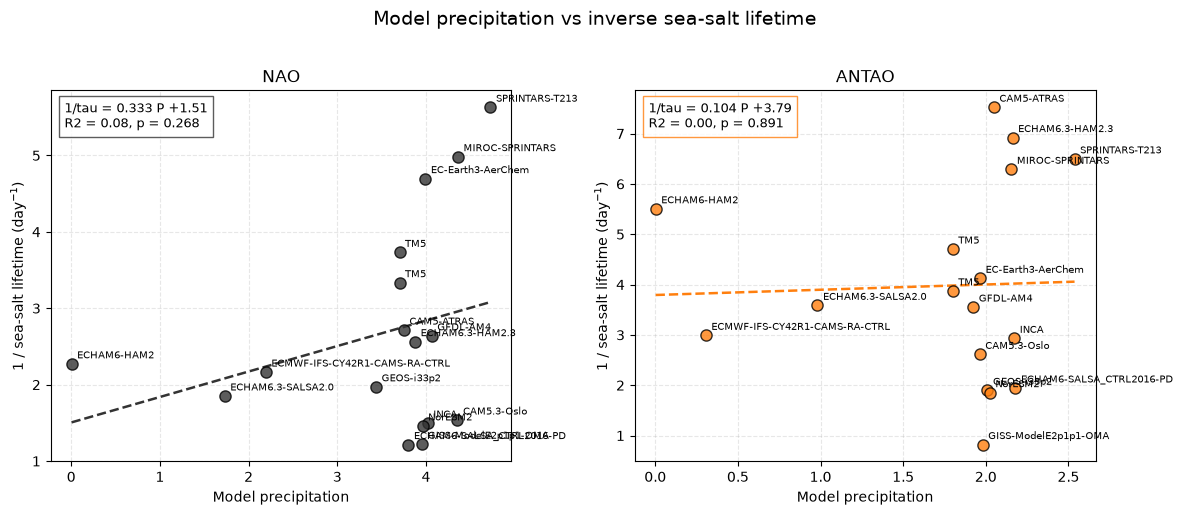

In [17]:
print("\n--- Figure S3: precipitation vs 1/lifetime_ss ---")


def scalar_value(value):
    """Return one finite float from a scalar or xarray aggregated value."""
    if value is None:
        return np.nan
    try:
        if hasattr(value, "values"):
            value = np.asarray(value.values)
        value = np.asarray(value, dtype=float)
        return float(np.nanmean(value)) if value.size else np.nan
    except (TypeError, ValueError):
        return np.nan


def gpcp_seasonal_mean(gpcp_ts, region_name):
    """Match the GPCP mean to the region's configured analysis time window."""
    if gpcp_ts is None:
        return np.nan

    t0, t1 = REGIONS[region_name]["time_slice"]

    if hasattr(gpcp_ts, "sel"):
        subset = gpcp_ts.sel(time=slice(t0, t1))
        return scalar_value(subset.mean("time", skipna=True))

    # Also supports a pandas Series indexed by datetime or monthly Period.
    if isinstance(gpcp_ts, pd.Series):
        index = pd.to_datetime(gpcp_ts.index.astype(str))
        subset = gpcp_ts[(index >= pd.Timestamp(t0)) & (index <= pd.Timestamp(t1))]
        return scalar_value(subset)

    return scalar_value(gpcp_ts)


# Build the plot tables directly from the seasonal aggregation DataFrame.
s3_df = model_seasonal_df.loc[
    model_seasonal_df["region"].isin(SOURCE_REGIONS),
    ["region", "model", "precip", "lifetime_ss"],
].replace([np.inf, -np.inf], np.nan).dropna().copy()
s3_df = s3_df.loc[s3_df["lifetime_ss"] > 0]
s3_df["inv_lifetime"] = 1.0 / s3_df["lifetime_ss"]

gpcp_comparison_rows = []
for region in SOURCE_REGIONS:
    gpcp_mean = gpcp_seasonal_mean(gpcp_monthly.get(region), region)
    if not np.isfinite(gpcp_mean):
        continue
    for _, row in s3_df.loc[s3_df["region"] == region].iterrows():
        gpcp_comparison_rows.append({
            "region": region,
            "model": row["model"],
            "model_precip": row["precip"],
            "gpcp_precip": gpcp_mean,
        })

gpcp_compare_df = pd.DataFrame(gpcp_comparison_rows)

print(f"Valid precipitation/lifetime rows: {len(s3_df)}")
for region in SOURCE_REGIONS:
    n_s3 = int((s3_df["region"] == region).sum()) if not s3_df.empty else 0
    n_gpcp = int((gpcp_compare_df["region"] == region).sum()) if not gpcp_compare_df.empty else 0
    print(f"  {region}: {n_s3} lifetime rows; {n_gpcp} model-vs-GPCP rows")


# -------------------------------------------------------------------------
# Plot 1: model precipitation versus inverse sea-salt lifetime
# -------------------------------------------------------------------------
ncols = 2
nrows = int(np.ceil(len(SOURCE_REGIONS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows), squeeze=False)

for idx, region in enumerate(SOURCE_REGIONS):
    ax = axes[idx // ncols, idx % ncols]
    color = REGION_COLORS.get(region, "#333333")

    sub = s3_df[s3_df["region"] == region].copy()

    if len(sub) < 2:
        ax.set_title(f"{region}: insufficient data (n={len(sub)})")
        ax.axis("off")
        continue

    x = sub["precip"].to_numpy(dtype=float)
    y = sub["inv_lifetime"].to_numpy(dtype=float)

    ax.scatter(
        x, y, color=color, edgecolor="black",
        s=65, alpha=0.8, zorder=3,
        label=f"Models (n={len(sub)})",
    )

    for _, row in sub.iterrows():
        ax.annotate(
            short_model_name(row["model"]),
            (row["precip"], row["inv_lifetime"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7,
        )

    if len(sub) >= 3 and np.unique(x).size >= 2:
        slope, intercept, r_value, p_value, _ = linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept

        ax.plot(x_line, y_line, "--", color=color, linewidth=1.8)
        ax.text(
            0.03, 0.97,
            f"1/tau = {slope:.3g} P {intercept:+.3g}\n"
            f"R2 = {r_value**2:.2f}, p = {p_value:.3f}",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            bbox=dict(facecolor="white", edgecolor=color, alpha=0.8),
        )

    ax.set_title(region)
    ax.set_xlabel("Model precipitation")
    ax.set_ylabel("1 / sea-salt lifetime (day$^{-1}$)")
    ax.grid(True, alpha=0.3, linestyle="--")

# Hide unused axes.
for idx in range(len(SOURCE_REGIONS), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

fig.suptitle("Model precipitation vs inverse sea-salt lifetime", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()




Valid AE/lifetime/precipitation rows: 32
  NAO: 16 model rows
  ANTAO: 16 model rows
Valid AE/lifetime/precipitation rows: 32
  NAO: 16 model rows
  ANTAO: 16 model rows


/tmp/ipykernel_4059620/1669526826.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


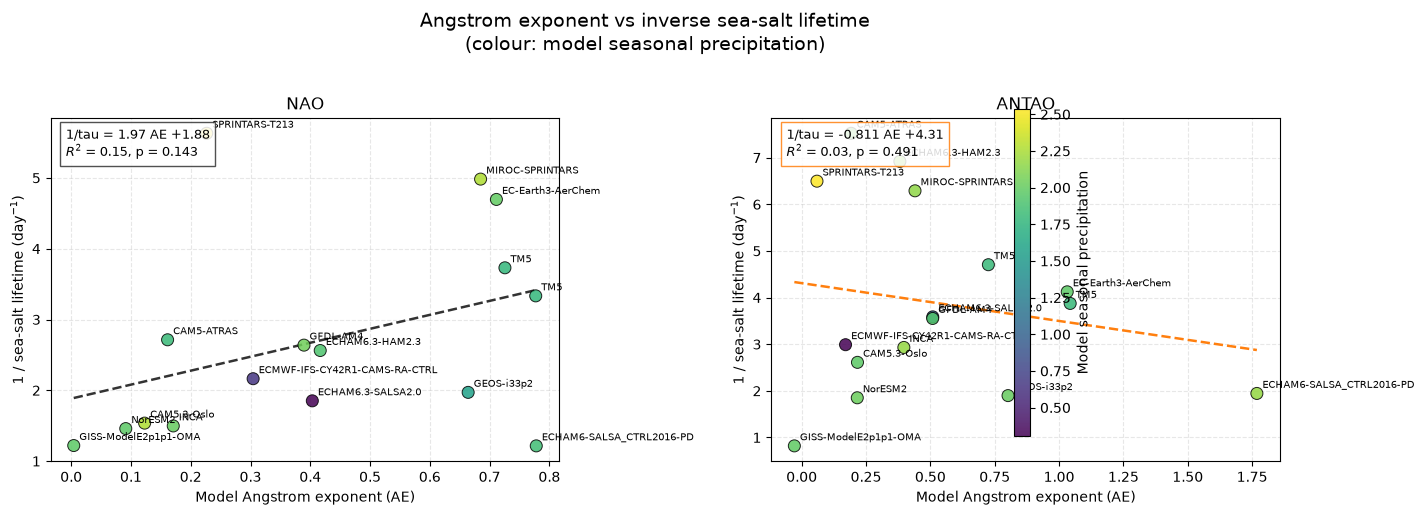

In [18]:
# -------------------------------------------------------------------------
# Plot: 1/lifetime_ss vs AE, coloured by model seasonal precipitation
# -------------------------------------------------------------------------
ae_lifetime_precip_df = model_seasonal_df.loc[
    model_seasonal_df["region"].isin(SOURCE_REGIONS),
    ["region", "model", "AE", "lifetime_ss", "precip"],
].rename(columns={"precip": "model_precip"})
ae_lifetime_precip_df = ae_lifetime_precip_df.replace([np.inf, -np.inf], np.nan).dropna().copy()
ae_lifetime_precip_df = ae_lifetime_precip_df.loc[ae_lifetime_precip_df["lifetime_ss"] > 0]
ae_lifetime_precip_df["inv_lifetime"] = 1.0 / ae_lifetime_precip_df["lifetime_ss"]
print(f"Valid AE/lifetime/precipitation rows: {len(ae_lifetime_precip_df)}")

if ae_lifetime_precip_df.empty:
    print("No models have finite AE, lifetime_ss, and precip simultaneously.")
    for region in SOURCE_REGIONS:
        region_df = model_seasonal_df.loc[model_seasonal_df["region"] == region]
        print(
            f"  {region}: "
            f"AE={region_df['AE'].notna().sum()}, "
            f"lifetime_ss={region_df['lifetime_ss'].notna().sum()}, "
            f"precip={region_df['precip'].notna().sum()}"
        )
else:
    for region in SOURCE_REGIONS:
        n = int((ae_lifetime_precip_df["region"] == region).sum())
        print(f"  {region}: {n} model rows")

print(f"Valid AE/lifetime/precipitation rows: {len(ae_lifetime_precip_df)}")
for region in SOURCE_REGIONS:
    n = (
        int((ae_lifetime_precip_df["region"] == region).sum())
        if not ae_lifetime_precip_df.empty else 0
    )
    print(f"  {region}: {n} model rows")


ncols = 2
nrows = int(np.ceil(len(SOURCE_REGIONS) / ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(13, 5 * nrows),
    squeeze=False,
)

scatter_for_cbar = None

for idx, region in enumerate(SOURCE_REGIONS):
    ax = axes[idx // ncols, idx % ncols]
    region_color = REGION_COLORS.get(region, "#333333")

    sub = ae_lifetime_precip_df[
        ae_lifetime_precip_df["region"] == region
    ].copy()

    if len(sub) < 2:
        ax.set_title(f"{region}: insufficient data (n={len(sub)})")
        ax.axis("off")
        continue

    x = sub["AE"].to_numpy(dtype=float)
    y = sub["inv_lifetime"].to_numpy(dtype=float)
    precip = sub["model_precip"].to_numpy(dtype=float)

    scatter_for_cbar = ax.scatter(
        x,
        y,
        c=precip,
        cmap="viridis",
        s=75,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.7,
        zorder=3,
    )

    for _, row in sub.iterrows():
        ax.annotate(
            short_model_name(row["model"]),
            (row["AE"], row["inv_lifetime"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7,
        )

    if len(sub) >= 3 and np.unique(x).size >= 2:
        slope, intercept, r_value, p_value, _ = linregress(x, y)

        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(
            x_line,
            slope * x_line + intercept,
            "--",
            color=region_color,
            linewidth=1.8,
        )

        ax.text(
            0.03, 0.97,
            f"1/tau = {slope:.3g} AE {intercept:+.3g}\n"
            f"$R^2$ = {r_value**2:.2f}, p = {p_value:.3f}",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            bbox=dict(facecolor="white", edgecolor=region_color, alpha=0.85),
        )

    ax.set_title(region)
    ax.set_xlabel("Model Angstrom exponent (AE)")
    ax.set_ylabel("1 / sea-salt lifetime (day$^{-1}$)")
    ax.grid(True, alpha=0.3, linestyle="--")

for idx in range(len(SOURCE_REGIONS), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

if scatter_for_cbar is not None:
    cbar = fig.colorbar(
        scatter_for_cbar,
        ax=axes.ravel().tolist(),
        pad=0.02,
        shrink=0.85,
    )
    cbar.set_label("Model seasonal precipitation")

fig.suptitle(
    "Angstrom exponent vs inverse sea-salt lifetime\n(colour: model seasonal precipitation)",
    y=1.02,
    fontsize=14,
)
fig.tight_layout()
plt.show()

In [ ]:
def plot_scatter_by_region(
    df,
    x_col,
    y_col,
    color_col=None,
    regions=None,
    x_label=None,
    y_label=None,
    color_label=None,
    title=None,
    annotate_models=True,
    use_model_numbers=False,
    fit_line=False,
    force_intercept_zero=False,
    cmap='viridis',
    save_fig=False,
    filename='scatter_by_region.png',
    figsize=(8, 6),
):
    """
    Generic scatter plot of any two columns from model_seasonal_df / model_monthly_df,
    optionally colored by a third column, faceted by region (colors) or filtered to
    a subset of regions.

    Parameters
    ----------
    df : pd.DataFrame
        model_seasonal_df or model_monthly_df (must contain 'region' and 'model' cols).
    x_col, y_col : str
        Column names to plot on x and y axes.
    color_col : str, optional
        Column used to color points (e.g. 'precip'). If None, points are colored
        by region instead.
    regions : list[str], optional
        Subset of regions to include. Defaults to all regions present in df.
    annotate_models : bool
        If True, label each point with its model name (or number).
    use_model_numbers : bool
        If True (and annotate_models), label points with an index number and
        print a model-index legend instead of full names.
    fit_line : bool
        If True, fit and draw a linear regression per region.
    force_intercept_zero : bool
        If True, fit through the origin (uncentered R^2); else standard OLS.
    """
    if df.empty:
        print(f"{df} is empty.")
        return

    regions = regions if regions is not None else sorted(df['region'].dropna().unique())

    cols_needed = {'model', 'region', x_col, y_col}
    if color_col:
        cols_needed.add(color_col)
    missing = cols_needed - set(df.columns)
    if missing:
        print(f"Missing columns in df: {missing}")
        return

    plot_df = df.loc[df['region'].isin(regions), list(cols_needed)].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

    if plot_df.empty:
        print("No valid rows after filtering NaN/inf.")
        return

    all_models = sorted(plot_df['model'].dropna().unique())
    model_to_num = {m: i + 1 for i, m in enumerate(all_models)}

    fig, ax = plt.subplots(figsize=figsize)
    region_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    scatter_for_cbar = None

    for idx, region in enumerate(regions):
        sub = plot_df.loc[plot_df['region'] == region]
        if sub.empty:
            print(f"Skipping {region}: no data.")
            continue

        x = sub[x_col].to_numpy(dtype=float)
        y = sub[y_col].to_numpy(dtype=float)

        if color_col:
            # Color by a data column (shared colorbar across regions);
            # marker edge indicates region for visual grouping.
            scatter_for_cbar = ax.scatter(
                x, y, c=sub[color_col].to_numpy(dtype=float),
                cmap=cmap, s=80, alpha=0.85,
                edgecolors=region_colors[idx % len(region_colors)],
                linewidth=1.5, zorder=3,
            )
        else:
            color = region_colors[idx % len(region_colors)]
            ax.scatter(
                x, y, s=80, alpha=0.7, color=color,
                edgecolors='black', linewidth=1.0, label=region.upper(), zorder=3,
            )

        if annotate_models:
            for _, row in sub.iterrows():
                txt = str(model_to_num[row['model']]) if use_model_numbers else str(row['model'])
                ax.annotate(
                    txt, (row[x_col], row[y_col]),
                    xytext=(4, 4), textcoords='offset points', fontsize=7,
                )

        if fit_line and len(sub) >= 2:
            fit_color = region_colors[idx % len(region_colors)]
            if force_intercept_zero:
                denom = np.dot(x, x)
                if denom <= 0:
                    continue
                slope = np.dot(x, y) / denom
                intercept = 0.0
                r2 = 1 - np.sum((y - slope * x) ** 2) / np.sum(y ** 2) if np.sum(y ** 2) > 0 else np.nan
                eq_str = f"y = {slope:.3g}x"
                r2_label = "Uncentered $R^2$"
            else:
                if np.unique(x).size < 2:
                    continue
                slope, intercept, r_value, _, _ = linregress(x, y)
                r2 = r_value ** 2
                sign = '+' if intercept >= 0 else '-'
                eq_str = f"y = {slope:.3g}x {sign} {abs(intercept):.3g}"
                r2_label = "$R^2$"

            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, '--', color=fit_color, linewidth=1.6)
            ax.text(
                0.02, 0.96 - idx * 0.09, f"{region.upper()}: {eq_str}\n{r2_label} = {r2:.3f}",
                transform=ax.transAxes, color=fit_color, fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75, edgecolor=fit_color),
            )

    if color_col and scatter_for_cbar is not None:
        cbar = fig.colorbar(scatter_for_cbar, ax=ax, pad=0.02)
        cbar.set_label(color_label or color_col)
    elif not color_col:
        ax.legend(title="Regions", loc="best")

    if use_model_numbers and annotate_models and all_models:
        legend_elements = [
            Line2D([0], [0], marker='', color='w', label=f"{i+1}: {m}")
            for i, m in enumerate(all_models)
        ]
        ax.legend(
            handles=legend_elements, title="Model Index Key",
            loc='upper center', bbox_to_anchor=(0.5, -0.15),
            fontsize=8, title_fontsize=9, ncol=2,
        )
        plt.subplots_adjust(bottom=0.3)

    ax.set_xlabel(x_label or x_col, fontsize=12, fontweight='bold')
    ax.set_ylabel(y_label or y_col, fontsize=12, fontweight='bold')
    ax.set_title(title or f"{y_col} vs {x_col} ({', '.join(regions)})", fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()

    if save_fig:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")

    plt.show()

In [ ]:
# Seasonal, colored by precip, fit line per region
plot_scatter_by_region(
    model_seasonal_df,
    x_col='AE', y_col='lifetime_ss', color_col='precip',
    regions=['NAO', 'ANTAO'],
    fit_line=True, use_model_numbers=True,
)

# Monthly data, no color column (region-colored), no fit
plot_scatter_by_region(
    model_monthly_df,
    x_col='SSA', y_col='MEC_ss',
    regions=SOURCE_REGIONS,
    annotate_models=False,
)
model_seasonal_df['inv_lifetime_so4'] = 1.0 / model_seasonal_df['lifetime_so4']

plot_scatter_by_region(
    model_seasonal_df,
    x_col='precip', y_col='inv_lifetime_so4', color_col='AE',
    y_label=r'1/$\tau_{SO_4}$ day$^{-1}$',
    x_label='precip',
    regions=['NAO', 'ANTAO'],
    fit_line=True, use_model_numbers=True,
)

NameError: name 'fig_s4_regions' is not defined

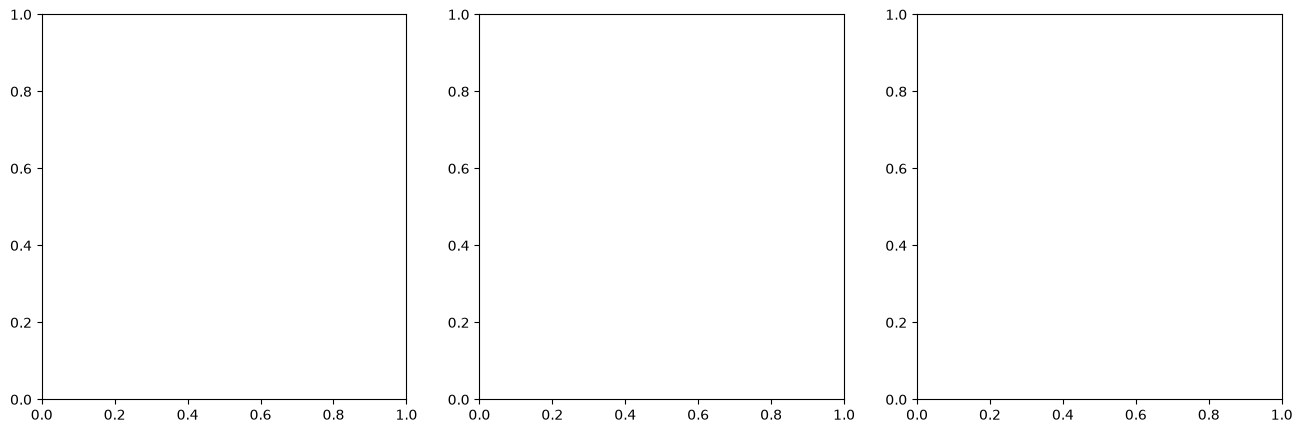

In [ ]:
# ── Fig. S4-style scatter: GPCP vs multi-model median precip ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panel_keys = ["amazon", "africa","outflow_af"]
colors = {"amazon": "tab:blue", "africa": "tab:orange", "outflow_af": "tab:green"}

for ax, rname in zip(axes, panel_keys):
    cfg  = fig_s4_regions[rname]
    sd   = scatter_data[rname]
    gpcp_vals   = sd["gpcp"]
    median_vals = sd["median"]
    e_lo        = sd["e_lo"]
    e_hi        = sd["e_hi"]
    r_val, p_val = sd["r"], sd["p"]
    color = colors[rname]

    # Error bars (IQR asymmetric)
    ax.errorbar(
        gpcp_vals, median_vals,
        yerr=[e_lo, e_hi],
        fmt="o", color=color, ecolor="gray",
        alpha=0.35, markersize=3, linewidth=0.6,
        label="_nolegend_",
    )

    # 1:1 dashed line
    max_val = max(gpcp_vals.max(), median_vals.max()) * 1.05
    ax.plot([0, max_val], [0, max_val], "k--", linewidth=1.2, label="1:1")

    # Annotate r and p-value
    p_str = f"{p_val:.2e}" if p_val >= 1e-300 else "< 10\u207b\u00b3\u2070\u2070"
    annot = "r = {:.3f}\np = {}".format(r_val, p_str)
    ax.text(0.05, 0.95, annot,
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel("GPCP precipitation (mm/day)", fontsize=11)
    ax.set_ylabel("AeroCom multi-model median precip (mm/day)", fontsize=11)
    ax.set_title("{} {}".format(cfg["panel"], cfg["label"]), fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

n_models = scatter_data["amazon"]["n_models"]
fig.suptitle(
    "Modelled vs GPCP precipitation \u2014 multi-model median ({} models)\n"
    "Error bars: interquartile range (IQR, 25th\u201375th percentile)".format(n_models),
    fontsize=11, y=1.01,
)
plt.tight_layout()

fig_path = os.path.join(project_root, "notebooks", "GPCP_vs_AeroCom_median_precip.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved figure to {}".format(fig_path))
plt.show()


## POLDER-GRASP homogenization

For each source region, the notebook compares the **regional model mean**
with the **POLDER-GRASP sampled mean** and fits a linear regression of the
form `sampled = a · regional + b`.

The fit is built from the AeroCom models that have valid values for both the
regional mean and the POLDER-sampled mean. After fitting, the observed
POLDER value is mapped back to a homogenized regional value by inversion:
`regional_homogenized = (sampled_obs - b) / a`.

In [ ]:
if USE_AGG_CACHE:
    print("USE_AGG_CACHE=True: skipping POLDER load (from parquet)")
else:
    polder_path = project_root / "Data" / "AP3_POLDER_Collocated" / "POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet"
    print(f"\nLoading POLDER observations: {polder_path}")

    polder_cols = ["time", "longitude", "latitude", "AOD_550", "AAOD_550", "AOD_440", "AOD_870"]
    polder_df = pd.read_parquet(polder_path, columns=polder_cols)

    polder_df["time"] = pd.to_datetime(polder_df["time"])
    polder_df["month"] = polder_df["time"].dt.to_period("M")
    polder_df["lon360"] = (polder_df["longitude"] + 360.0) % 360.0

    with np.errstate(divide="ignore", invalid="ignore"):
        polder_df["SSA"] = 1.0 - polder_df["AAOD_550"] / polder_df["AOD_550"]
        polder_df["AE"] = -np.log(polder_df["AOD_550"] / polder_df["AOD_870"]) / np.log(550.0 / 870.0)

    polder_df = polder_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["SSA", "AE", "AAOD_550", "AOD_550"])
    print(f"POLDER rows after filtering: {len(polder_df)}")

    # Build masks once if not already present
    if "masks" not in globals() or not masks:
        template = data[ss_models[0]]["od550aer"].isel(time=0)
        masks = setup.create_analysis_masks(template, ANALYSIS_REGIONS, region=REGIONS, surface_type=None)

    def polder_mask_filter(df, region_name, masks_dict=masks, reg_cfg=REGIONS):
        """
        Filter POLDER rows to a region using the existing xarray regional mask
        (same mask REGIONS/masks used for model and GPCP aggregation), applying
        the region's configured time window as well.
        """
        if region_name not in masks_dict:
            raise KeyError(f"No existing mask found for region {region_name!r}.")

        cfg = reg_cfg[region_name]
        mask = masks_dict[region_name]

        work = df.copy()
        work["lon360"] = (work["longitude"] + 360.0) % 360.0

        point_mask = mask.interp(
            lon=xr.DataArray(work["lon360"].to_numpy(), dims="points"),
            lat=xr.DataArray(work["latitude"].to_numpy(), dims="points"),
            method="nearest",
        )
        work = work[np.asarray(point_mask.values) > 0.5].copy()

        t0, t1 = cfg["time_slice"]
        work = work[
            (work["time"] >= pd.Timestamp(t0)) & (work["time"] <= pd.Timestamp(t1))
        ].copy()
        return work

    def polder_monthly_means_mask(df, region_name, masks_dict=masks, reg_cfg=REGIONS):
        """Area-weighted POLDER monthly means using the existing regional mask."""
        work = polder_mask_filter(df, region_name, masks_dict, reg_cfg)

        if work.empty:
            return pd.DataFrame(columns=["month", "time", "SSA", "AE", "AAOD_550", "AOD_550", "n"])

        work["coslat"] = np.cos(np.deg2rad(work["latitude"]))
        rows = []
        for month, group in work.groupby("month"):
            if len(group) < 3:
                continue
            weights = group["coslat"].to_numpy()
            rows.append({
                "month": month,
                "time": pd.Timestamp(month.start_time),
                "SSA": np.average(group["SSA"], weights=weights),
                "AE": np.average(group["AE"], weights=weights),
                "AAOD_550": np.average(group["AAOD_550"], weights=weights),
                "AOD_550": np.average(group["AOD_550"], weights=weights),
                "n": len(group),
            })
        return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)

    polder_monthly = {
        region: polder_monthly_means_mask(polder_df, region)
        for region in ANALYSIS_REGIONS
    }

    print("POLDER monthly means per region:")
    for region, df_reg in polder_monthly.items():
        print(f"  {region}: {len(df_reg)} months")

In [ ]:
def sample_model_var_at_polder(model_da, polder_sub):
    """Sample model monthly AAOD at POLDER locations/times; return weighted mean."""
    if model_da is None or polder_sub.empty:
        return np.nan
    lat_vals = model_da.lat.values
    lon_vals = model_da.lon.values
    lat_idx = np.abs(lat_vals[:, None] - polder_sub['latitude'].values[None, :]).argmin(axis=0)
    lon_idx = np.abs(lon_vals[:, None] - polder_sub['longitude'].values[None, :]).argmin(axis=0)
    times = pd.to_datetime(model_da.time.values)
    polder_times = pd.to_datetime(polder_sub['time'].values)
    month_idx = np.array([
        np.argmin(np.abs(times - pd.Timestamp(t).to_period('M').to_timestamp()))
        for t in polder_times
    ])
    vals = model_da.values[month_idx, lat_idx, lon_idx]
    weights = np.cos(np.deg2rad(polder_sub['latitude'].values))
    finite = np.isfinite(vals)
    if finite.sum() < 3:
        return np.nan
    return float(np.average(vals[finite], weights=weights[finite]))


def _regional_dict_from_df(df, region, var_col):
    """model_seasonal_df -> {model: value} for one region/variable, NaN dropped."""
    if var_col not in df.columns:
        return {}
    sub = df.loc[df['region'] == region, ['model', var_col]].dropna()
    return dict(zip(sub['model'], sub[var_col].astype(float)))


def _homogenize_polder_variable(model_seasonal_df, polder_raw, obs_col, model_var_key,
                                    sampler_fn, var_label, regions):
    """Homogenize a regional POLDER-observed mean via model regional-vs-sampled regression.

    Uses `model_seasonal_df` (region/model wide table) for the regional means and
    the shared `masks`/REGIONS-based `polder_mask_filter` for spatial/temporal
    subsetting of POLDER, so this stays consistent with the model & GPCP
    aggregation masks used elsewhere in the notebook.

    Returns
    -------
    homogenized : dict[region] -> float
    details : dict[region] -> dict
    """
    homogenized = {}
    details = {}
    print(f'\n--- POLDER-GRASP homogenization ({var_label}) ---')
    for region in ANALYSIS_REGIONS:
        cfg = regions[region]
        sub = polder_mask_filter(polder_raw, region, masks, regions)
        if sub.empty:
            print(f'  {region}: no POLDER samples')
            details[region] = {'skipped': True}
            continue
        obs_sampled = float(np.average(sub[obs_col], weights=np.cos(np.deg2rad(sub['latitude']))))

        if region == OUTFLOW_REGION:
            homogenized[region] = obs_sampled
            details[region] = {'skipped': True, 'obs_sampled': obs_sampled}
            print(f'  {region}: using raw sampled {var_label}={obs_sampled:.5f} (no homogenization)')
            continue

        regional = _regional_dict_from_df(model_seasonal_df, region, model_var_key)
        sampled = {}
        for model in regional:
            da = data_derived[model].get(model_var_key)
            s = sampler_fn(da, sub)
            if np.isfinite(s) and np.isfinite(regional[model]):
                sampled[model] = s
        common = [m for m in regional if m in sampled]
        if len(common) < 3:
            print(f'  {region}: homogenization skipped (only {len(common)} models); '
                    f'falling back to raw sampled {var_label}={obs_sampled:.5f}')
            homogenized[region] = obs_sampled
            details[region] = {'skipped': True, 'obs_sampled': obs_sampled}
            continue

        x = np.array([regional[m] for m in common])
        y = np.array([sampled[m] for m in common])
        X = np.column_stack([x, np.ones(len(x))])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        a, b = float(coeffs[0]), float(coeffs[1])
        y_pred = a * x + b
        r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
        homogenized_regional = (obs_sampled - b) / a if a != 0 else np.nan
        homogenized[region] = homogenized_regional
        details[region] = {
            'skipped': False, 'models': common, 'x': x, 'y': y,
            'a': a, 'b': b, 'r2': r2, 'obs_sampled': obs_sampled,
            'homogenized': homogenized_regional,
        }
        print(f'  {region}: sampled = {a:.4f}*regional + {b:.4f}  (R^2={r2:.3f}, n={len(common)})')
        print(f'    raw sampled {var_label}={obs_sampled:.5f} -> '
                f'homogenized regional {var_label}={homogenized_regional:.5f}')
    return homogenized, details

In [ ]:
# HOMOG_SPECS = {
#     'AAOD': dict(obs_col='AAOD_550', model_var_key='abs550aer'),
#     'AOD':  dict(obs_col='AOD_550',  model_var_key='od550aer'),
#     'SSA':  dict(obs_col='SSA',      model_var_key='SSA'),
# }
# homog_results = {}
# for label, kw in HOMOG_SPECS.items():
#     homog_results[label] = _homogenize_polder_variable(
#         model_seasonal_df, polder_df, sampler_fn=sample_model_var_at_polder,
#         var_label=label, regions=REGIONS, **kw,
#     )
# --- Run POLDER-GRASP homogenization for AAOD and SSA -----------------------
if POLDER_HOMOGENIZE:
    aaod_homogenized, aaod_homog_details = _homogenize_polder_variable(
        model_seasonal_df, polder_df,
        obs_col='AAOD_550', model_var_key='abs550aer',
        sampler_fn=sample_model_var_at_polder,
        var_label='AAOD', regions=REGIONS,
    )
else:
    aaod_homogenized, aaod_homog_details = {}, {}
    print('POLDER_HOMOGENIZE=False: skipping AAOD homogenization')

if SSA_POLDER_HOMOGENIZE:
    ssa_homogenized, ssa_homog_details = _homogenize_polder_variable(
        model_seasonal_df, polder_df,
        obs_col='SSA', model_var_key='SSA',
        sampler_fn=sample_model_var_at_polder,
        var_label='SSA', regions=REGIONS,
    )
else:
    ssa_homogenized, ssa_homog_details = {}, {}
    print('SSA_POLDER_HOMOGENIZE=False: skipping SSA homogenization')